## Purpose

This notebook compares four methods for pricing a call option:
1) Black-Scholes Analytic
2) Black-Scholes Numerical
3) Binomial Tree
4) Monte Carlo


In [10]:
import numpy as np
from scipy import special
import matplotlib.pyplot as plt

# Meta Parameters
dS = 0.01
max_stock_price = 140

# Parameters
stock_price = np.arange(0, max_stock_price, dS)[1:]
expiry_time = 0.1
volatility = 0.3
drift = 0.03
strike_price = 100
risk_free = 0.05

## Black-Scholes Analytic

In this method the analytical solution to the Black-Scholes equation with the call option expiry value as a boundary condition is used. The solution is as follows

$$ C = S N \left( d_1 \right) - K e^{-rt} N \left(d_2 \right) ,$$
$$ d_1 = \frac{\text{ln} \left( \frac{S}{K} \right) + \left( r + \frac{\sigma^2}{2} \right) t}{\sigma \sqrt{t}} ,$$
$$ d_2 = d_1 - \sigma \sqrt{t} .$$

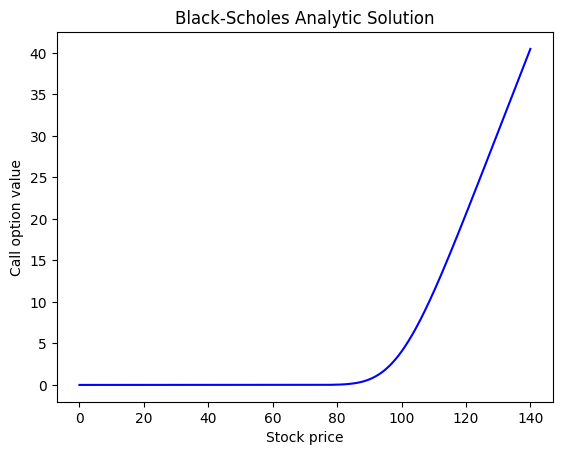

In [11]:
# Calculating d1 and d2 terms
d1 = (np.log(stock_price / strike_price) + (risk_free + volatility**2 / 2) * expiry_time) / (volatility * np.sqrt(expiry_time))
d2 = d1 - volatility * np.sqrt(expiry_time)

# Calculating call price
Black_Scholes_Analytic = stock_price * 1/2 * (1 + special.erf(d1 / np.sqrt(2))) - strike_price * np.exp(-risk_free * expiry_time) * 1/2 * (1 + special.erf(d2 / np.sqrt(2)))

plt.title("Black-Scholes Analytic Solution")
plt.plot(stock_price, Black_Scholes_Analytic, color="blue")
plt.xlabel("Stock price")
plt.ylabel("Call option value")
plt.show()

## Black-Scholes Numerical

In this method we transform the Black-Scholes equation into the heat equation and then apply an explicit numerical method to generate an approximate solution. Starting with the Black-Scholes equation we have

$$ \frac{\partial V}{\partial t} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + r S \frac{\partial V}{\partial S} - r V = 0 .$$

Applying a set of transformation we end up with the heat equation

$$ \frac{\partial u}{\partial \tau} = \frac{\partial^2 u}{\partial x^2} ,$$

where the boundary conditions are 

$$ u(x,0) = \text{max} \left( e^{\frac{1}{2} (k+1) x} - e^{\frac{1}{2} (k-1) x} , 0 \right) .$$

To convert our solution back to the original problem we apply the inverse of the following transformations

$$ S = K e^{x} ,$$
$$ t = T - \frac{\tau}{\frac{1}{2} \sigma^2} ,$$
$$ k = \frac{r}{\frac{1}{2} \sigma^2} ,$$
$$ C(S,t) = K e^{-\frac{1}{2} (k-1) x - \frac{1}{4} (k+1)^2 \tau} u(x, \tau).$$

Since the Black-Scholes equation is written in terms of forward time $t$ while we want to express our solution in terms of time to expiry $T$, we evaluate $C(S, t)$ at $t=0$. 

To solve the heat equation numerically we employ the Explicit Finite-difference method.

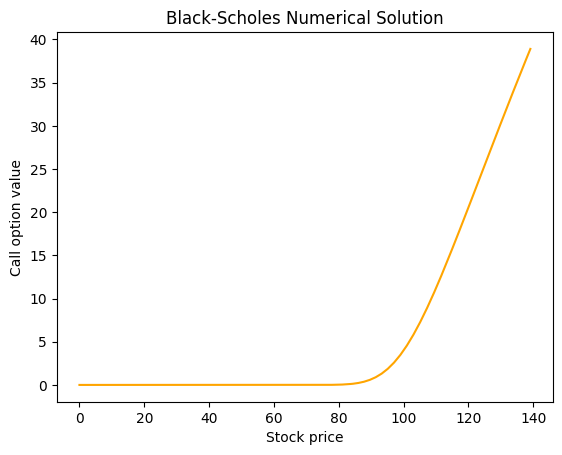

In [12]:
dtau = 0.00005
dx = 0.01
min_x = -10

tau = np.arange(0, 1/2 * volatility**2 * expiry_time, dtau)
x = np.arange(min_x, np.log(max_stock_price / strike_price), dx)

k = risk_free / (1/2 * volatility**2)

heat_equation_solution = np.zeros((len(tau), len(x)))

# Applying initial condition
heat_equation_solution[0] = np.max([np.exp(1/2 * (k+1) * x) - np.exp(1/2 * (k-1) * x), heat_equation_solution[0]], axis=0)

alpha = dtau / dx**2
for i in range(len(heat_equation_solution) - 1):

    heat_equation_solution[i+1] = alpha * np.roll(heat_equation_solution[i], 1) + (1 - 2 * alpha) * heat_equation_solution[i] + alpha * np.roll(heat_equation_solution[i], -1)
    heat_equation_solution[i+1][0] = 0
    heat_equation_solution[i+1][-1] = heat_equation_solution[0][-1]

# Converting solution back into Black-Scholes form

stock_price_numerical = strike_price * np.exp(x)
Black_Scholes_Numerical = np.zeros((len(tau), len(x)))
for j in range(len(tau)):

    Black_Scholes_Numerical[j] = strike_price * np.exp( -1/2 * (k-1) * x - 1/4 * (k+1)**2 * tau[j]) * heat_equation_solution[j]

plt.title("Black-Scholes Numerical Solution")
plt.plot(stock_price_numerical, Black_Scholes_Numerical[-1], color="orange")
plt.xlabel("Stock price")
plt.ylabel("Call option value")
plt.show()

## Binomial Tree

The binomial tree method relies on the idea of a replicating portfolio. Given two possible movements for a stock, the no arbitrage principle can be used to deduce a fair value for the option. We then repeat this process in a tree like fashion to obtain the value of an option at multiple stock prices at a given time. 

Given that the underlying price can either increase by a fixed amount $u$ or decrease by a fixed amount $d$ with probabilities $p$ and $1-p$ respectively we can calculate the value of an option using risk neutral valuation. Hence we have

$$ V_{i,j} = \left[ p V_{i+1,j+1} + (1-p) V_{i-1,j+1} \right] e^{-r \Delta t} ,$$

where $V_{i,j}$ is the value of the option at the ith row and jth column while $\Delta t$ is the time step between columns. Since we know the value of the option at expiry, for a European call we have

$$ V_{i,n} = \text{Max} \left( S u^i d^{ \ n-i} - K ,0\right) , \ i = 0,1,\dots,n $$

where $S$ is the central stock price and $i$ increases from the bottom of the tree to the top within nth column. 

In the Cox-Ross-Rubinstein Model we have

$$ u = e^{\sigma \sqrt{\Delta t}} ,$$
$$ d = e^{-\sigma \sqrt{\Delta t}} ,$$
$$ p = \frac{e^{r \Delta t} - d}{u - d} .$$


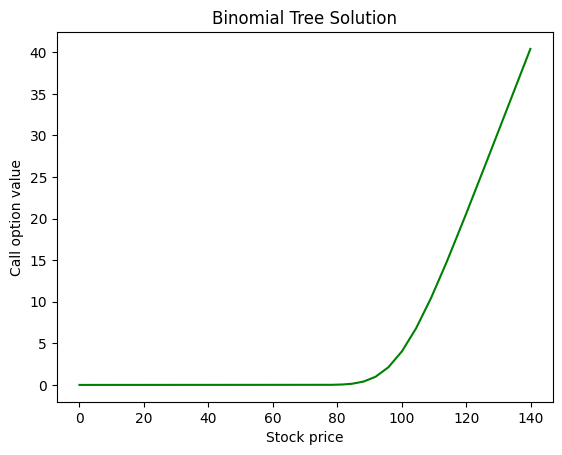

In [13]:
dt = 0.005
dS = 0.1
stock_price_binomial = np.arange(0, max_stock_price, dS)[1:]

u = np.exp(volatility * np.sqrt(dt))
d = np.exp(-volatility * np.sqrt(dt))
p = (np.exp(risk_free * dt) - d) / (u - d)
discount = np.exp(-risk_free * dt)

N = int(round(expiry_time / dt))

# Creating stock price tree
j = np.arange(N + 1)
terminal_prices = stock_price_binomial[:, None] * u**j[None, :] * d**(N - j)[None, :]

# Setting up the intial conditions based off the expiry value of the call option
values = np.maximum(terminal_prices - strike_price, 0.0)

# Backward induction: discounted risk-neutral expectation at each step
for _ in range(N):
    values = discount * (p * values[:, 1:] + (1 - p) * values[:, :-1])

binomial = values[:, 0]

plt.title("Binomial Tree Solution")
plt.plot(stock_price_binomial, binomial, color="green")
plt.xlabel("Stock price")
plt.ylabel("Call option value")
plt.show()

## Monte Carlo

This method relies on the concept of risk-neutral valuation. We simulate many paths of stock movement via geometric Brownian motion. We then use the paths to calculate the discounted expected value of the option. More explicitly we have

$$ S' = S e^{\left( r - \frac{\sigma^2}{2} \right) t + \sigma W_t} ,$$
$$ C(S, t) = \mathbb{E} \left[ C(S', T) \right] e^{-r t} .$$

Via the definition of $C(S, t)$ we know that

$$ C(S, T) = \text{Max} \left( S - K, 0 \right) .$$

Hence we have

$$ C(S, t) = \mathbb{E} \left[ \text{Max} \left( S' - K \right) \right] e^{-r t} .$$



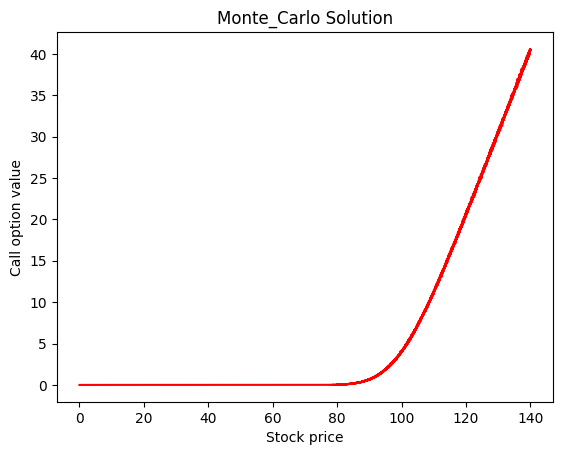

Monte Carlo Error (N=10000): 0.03555834477082823
Monte Carlo Error (N=1000): 0.36377305521909803
Monte Carlo Error (N=100): 3.500715857221889
Monte Carlo Error (N=10): 35.241838967981785


In [29]:
def Monte_Carlo_Method(stock_price_array, N): 

    Monte_Carlo_array = np.zeros(len(stock_price_array))
    sample_size = N

    for i in range(1, len(Monte_Carlo)):

        brownian_motion = np.random.normal(loc = 0, scale = np.sqrt(expiry_time), size = sample_size)
        stock_future_prices = stock_price[i] * np.exp((risk_free - volatility**2 / 2) * expiry_time + volatility * brownian_motion)
        call_valuation = np.max([stock_future_prices - strike_price, np.zeros(sample_size)], axis=0)
        Monte_Carlo_array[i] = np.average(call_valuation) * np.exp(-risk_free * expiry_time)

    return Monte_Carlo_array

Monte_Carlo = Monte_Carlo_Method(stock_price, 10000)

plt.title("Monte_Carlo Solution")
plt.plot(stock_price, Monte_Carlo, color="red")
plt.xlabel("Stock price")
plt.ylabel("Call option value")
plt.show()


Monte_Carlo_Error = np.sum((Monte_Carlo - Black_Scholes_Analytic)**2 * dS) / max_stock_price
print(f"Monte Carlo Error (N=10000): {Monte_Carlo_Error}")

Monte_Carlo_Error = np.sum((Monte_Carlo_Method(stock_price, 1000) - Black_Scholes_Analytic)**2 * dS) / max_stock_price
print(f"Monte Carlo Error (N=1000): {Monte_Carlo_Error}")

Monte_Carlo_Error = np.sum((Monte_Carlo_Method(stock_price, 100) - Black_Scholes_Analytic)**2 * dS) / max_stock_price
print(f"Monte Carlo Error (N=100): {Monte_Carlo_Error}")

Monte_Carlo_Error = np.sum((Monte_Carlo_Method(stock_price, 10) - Black_Scholes_Analytic)**2 * dS) / max_stock_price
print(f"Monte Carlo Error (N=10): {Monte_Carlo_Error}")


## Comparison of Methods

Monte Carlo Error: 4.845638500597844


ValueError: operands could not be broadcast together with shapes (1034,) (13999,) 

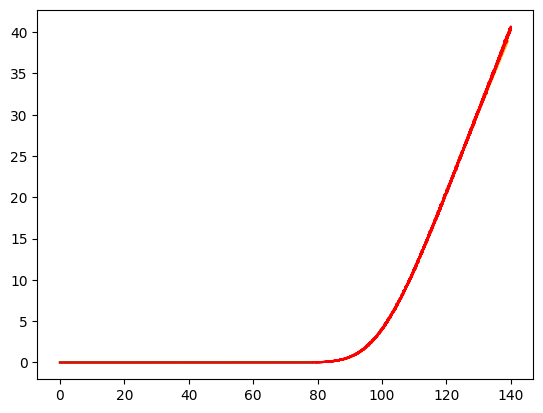

In [ ]:
# Plotting all methods at the same time
plt.plot(stock_price, Black_Scholes_Analytic, color="blue")
plt.plot(stock_price_numerical, Black_Scholes_Numerical[-1], color="orange")
plt.plot(stock_price_binomial, binomial, color="green")
plt.plot(stock_price, Monte_Carlo, color="red")

plt.title("All Solutions")
plt.xlabel("Stock price")
plt.ylabel("Call option value")
plt.show()